# 3. Model Training

## Summary
This notebook defines and trains the LSTM neural network based on the "DronePrint" architecture.

Steps involved:
1. Load the extracted features (`X`) and labels (`y`) from Notebook 02.
2. Split the data into Training, Validation, and Test sets.
3. Build the DronePrint LSTM architecture (2 stacked layers, hidden state size 32).
4. Train the model for 500 epochs using the Adam optimizer (lr=0.0001).
5. Save the model checkpoint that achieves the lowest validation loss.
6. Visualize the training/validation loss and accuracy.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


In [3]:
# Load the features and labels saved from Notebook 02
FEATURE_DIR = "./features"

X = np.load(os.path.join(FEATURE_DIR, 'X_features.npy'))
y = np.load(os.path.join(FEATURE_DIR, 'y_labels.npy'))
label_classes = np.load(os.path.join(FEATURE_DIR, 'label_classes.npy'), allow_pickle=True)

print(f"Loaded X shape: {X.shape}") # Should be (Samples, 10, 13)
print(f"Loaded y shape: {y.shape}")
print(f"Classes: {label_classes}")

# 1. Split into Train (80%) and Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 2. Split Temp into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Identify the number of time steps, features, and classes
TIME_STEPS = X.shape[1]
N_FEATURES = X.shape[2]
NUM_CLASSES = len(np.unique(y))

Loaded X shape: (33659, 10, 13)
Loaded y shape: (33659,)
Classes: ['drone' 'non_drone']
Training set: 26927 samples
Validation set: 3366 samples
Test set: 3366 samples


In [4]:
def build_droneprint_model(time_steps, n_features, num_classes):
    """
    Constructs the LSTM network exactly as described in the DronePrint paper:
    - Two stacked LSTM layers
    - Hidden state size of 32
    """
    model = Sequential()
    
    # Input Layer
    model.add(Input(shape=(time_steps, n_features)))
    
    # First Stacked LSTM Layer (return_sequences=True is required to stack LSTMs)
    model.add(LSTM(units=32, return_sequences=True, name="LSTM_1"))
    
    # Second Stacked LSTM Layer
    model.add(LSTM(units=32, return_sequences=False, name="LSTM_2"))
    
    # Output Layer (Softmax for classification)
    model.add(Dense(units=num_classes, activation='softmax', name="Output_Layer"))
    
    return model

# Initialize the model
model = build_droneprint_model(TIME_STEPS, N_FEATURES, NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 10, 32)         │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,274 (55.76 KB)

 Trainable params: 14,274 (55.76 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# The paper specifies the Adam optimizer with a learning rate of 0.0001
optimizer = Adam(learning_rate=0.0001)

# Compile the model
# We use sparse_categorical_crossentropy because our labels are integers (0, 1) not one-hot encoded
model.compile(
    loss='sparse_categorical_crossentropy', 
    optimizer=optimizer, 
    metrics=['accuracy']
)

# Ensure the models directory exists
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

# The paper specifies selecting the model that outputs the lowest validation loss.
# ModelCheckpoint will monitor 'val_loss' and only save the best one over the 500 epochs.
checkpoint_path = os.path.join(MODEL_DIR, "droneprint_best_model.keras")

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,    # Only save if the validation loss improves
    mode='min',             # We want to minimize validation loss
    verbose=1
)

In [6]:
# Training hyperparameters
EPOCHS = 500       # As specified in the paper
BATCH_SIZE = 32    # Standard batch size

print("Starting training...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint_callback],
    verbose=1 # Change to 0 if you don't want a massive output log
)

print("\nTraining complete! Best model saved to:", checkpoint_path)

Starting training...
Epoch 1/500
833/842 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8696 - loss: 0.3340
Epoch 1: val_loss improved from None to 0.00893, saving model to ./models\droneprint_best_model.keras

Epoch 1: finished saving model to ./models\droneprint_best_model.keras
842/842 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9486 - loss: 0.1477 - val_accuracy: 0.9976 - val_loss: 0.0089
Epoch 2/500
839/842 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9981 - loss: 0.0074
Epoch 2: val_loss improved from 0.00893 to 0.00465, saving model to ./models\droneprint_best_model.keras

Epoch 2: finished saving model to ./models\droneprint_best_model.keras
842/842 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9985 - loss: 0.0056 - val_accuracy: 0.9988 - val_loss: 0.0046
Epoch 3/500
833/842 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9989 - loss: 0.0031
Epoch 3: val_loss improved from 0.00465 to 0.00405, saving model to ./models\droneprint_best_model.keras

Epoch 3: finished saving mo

Test Set Accuracy (Best Model): 99.97%
Test Set Loss (Best Model): 0.0019


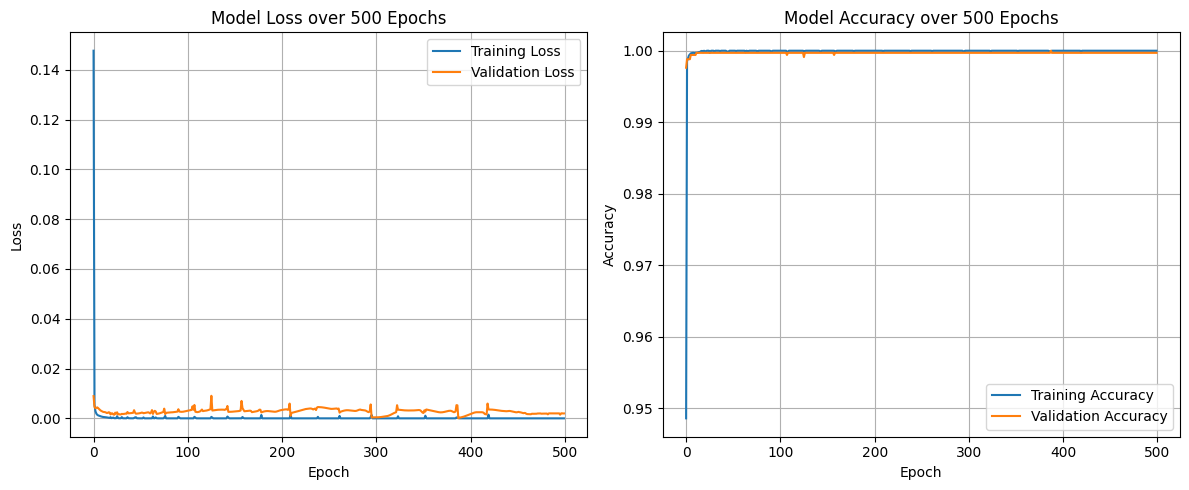

In [7]:
# Load the best model (the one with the lowest validation loss)
best_model = tf.keras.models.load_model(checkpoint_path)

# Evaluate on the unseen Test Set
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Set Accuracy (Best Model): {test_accuracy * 100:.2f}%")
print(f"Test Set Loss (Best Model): {test_loss:.4f}")

# Plot Training vs Validation Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over 500 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training vs Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over 500 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()